This demo shows how to align video recordings with ephys data when using the camera's strobe function.

In [35]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from climbing_analysis.ephys.events import detect_camera_on

Start by loading the sample analog data and checking the available keys. This data was recorded using the Open Ephys acquisition system, but this code is designed to work with any analog signal as long as you have the acquisition sample rate and the camera frame rate.

In [36]:
# create data path
project_root = Path.cwd().parent

data_path = project_root / 'examples' / 'sample_data' / 'continuous_event_test_data.npz'

# load test data
data = np.load(data_path)
print(f"Available arrays: {data.files}")

Available arrays: ['signal', 'sample_rate', 'camera_fps']


Create variables for the analog signal (`signal`, voltage/arbitrary units), acquisition system sampling rate (`sample_rate`, Hz), and camera frame rate (`fps`, Hz).

In [37]:
# create variables
signal = data['signal']
sample_rate = data['sample_rate']
fps = data['camera_fps']

For this demo, the `signal` variable will need to be padded due to the short length (700 samples, ~23ms). This is an unnecessary intermediate step for test cases given that most ephys recordings will be significantly longer than this.

In [38]:
# pad signal snippet
signal_pad = np.pad(signal, 1000, mode='minimum')

With the padded signal `signal_pad`, acquisition sample rate `sample_rate`, and the camera frame rate `fps`, we can identify the indices where camera frames were captured by running `detect_camera_on`, which will return a pandas dataframe containing information about the frame captures relative to the ephys recording. The argument `min_bout_duration` is useful for scenarios where ephys recordings are continuous and video recordings are discontinuous by allowing you to filter for edge cases where video recordings are triggered without the subject being in frame. For this example, however, we will set the `min_bout_duration` to 0.0 to collect all data.

In [39]:
# extract the frame captures
_, _, _, fc_df = detect_camera_on(signal_pad, sample_rate, '', frame_rate=fps, min_bout_duration=0.0, save_events=False)

# examine data frame
fc_df.head()

,video_index,frame_id,sample_index
0,0,0,1277
1,0,1,1427
2,0,2,1577


We can plot the frame capture indices against the analog data recorded on the ephys acquisition system to see that the frames line up with the strobe.

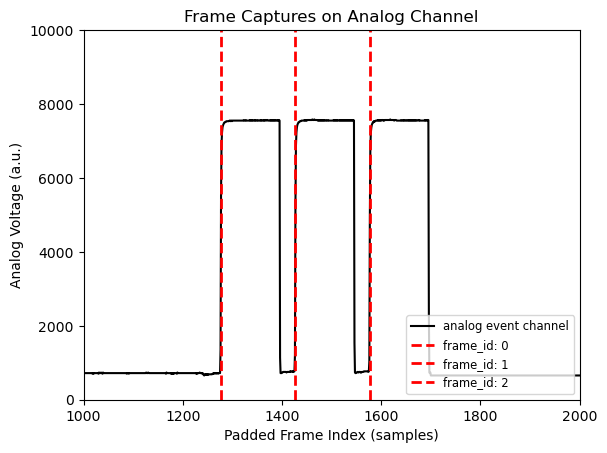

In [ ]:
# plot results

plt.plot(signal_pad,label='analog event channel', color='black') # padded signal

# loop through sample indices
for i, x in enumerate(fc_df['sample_index']):
    plt.axvline(x, linestyle='--', linewidth=2, color='red', label=f'frame_id: {i}')
plt.ylim(0,10000.) 
plt.title('Frame Captures on Analog Channel')
plt.xlabel('Padded Frame Index (samples)')
plt.ylabel('Analog Voltage (a.u.)')
plt.xlim([1000,2000]) # zoom in on three captures
plt.legend(fontsize='small', loc='lower right')
plt.show()